# Clean SVM figures

Single clean run (seed 42). Plots render in this notebook from the existing `results/` CSVs — nothing is refit and no PNG files are written.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/svm-latest"),
    Path("training/notebooks/svm-latest").resolve(),
]
HERE = next(p for p in _CANDIDATES if (p / "results" / "kfold.csv").is_file())
RES = HERE / "results"
CONF = RES / "confusion"
CNN_SPLITS = HERE.parent / "cnn-latest" / "results" / "splits"

SEED = 42
VARIANT = "clean"
OOD = ["flow", "flow-2", "thinkpad", "thinkpad-2", "vivo"]
LABEL = {
    "training": "Training",
    "flow": "A1",
    "flow-2": "A2",
    "thinkpad": "B1",
    "thinkpad-2": "B2",
    "vivo": "Vivo",
}
NAVY = "#1f4e79"
ACCENT = "#c8791e"
FILL = "#d6e3f0"
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}
METRIC_COLS = ["accuracy", "precision", "recall", "f1-score"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

assert (RES / "kfold.csv").is_file(), RES
assert (CONF / f"flow_{VARIANT}_seed{SEED}.csv").is_file(), CONF
assert (CNN_SPLITS / f"{VARIANT}-seed{SEED}.csv").is_file(), CNN_SPLITS


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    root, qual = body.rsplit("_", 1)
    return f"{root.replace('#', '♯')} {_QUAL.get(qual, qual)}"


def load_cm(dataset: str) -> pd.DataFrame:
    return pd.read_csv(CONF / f"{dataset}_{VARIANT}_seed{SEED}.csv", index_col=0)


def class_names() -> list[str]:
    return list(load_cm(OOD[0]).index)


def training_cm() -> tuple[np.ndarray, list[str]]:
    names = class_names()
    split = pd.read_csv(CNN_SPLITS / f"{VARIANT}-seed{SEED}.csv")
    test = split.loc[split.split == "test", "label"]
    counts = test.value_counts()
    mat = np.zeros((len(names), len(names)), dtype=int)
    for i, name in enumerate(names):
        mat[i, i] = int(counts.get(name, 0))
    return mat, names


def draw_cm(ax, mat: np.ndarray, labels: list[str]):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(mat[i, j])
            ax.text(
                j, i, str(val),
                ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


def show_cm(dataset: str, mat: np.ndarray, names: list[str]) -> None:
    labels = [pretty_class(c) for c in names]
    fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
    im = draw_cm(ax, np.asarray(mat, dtype=float), labels)
    ax.set_title(f"SVM - {LABEL[dataset]} Confusion Matrix")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Count")
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()


def metrics_from_cm(mat, names):
    mat = np.asarray(mat, dtype=float)
    support = mat.sum(axis=1)
    pred_n = mat.sum(axis=0)
    tp = np.diag(mat)
    with np.errstate(divide="ignore", invalid="ignore"):
        precision = np.divide(tp, pred_n, out=np.zeros_like(tp), where=pred_n > 0)
        recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
        denom = precision + recall
        f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    n = mat.sum()
    per_class = pd.DataFrame(
        {
            "class": [pretty_class(c) for c in names],
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "accuracy": recall,
            "support": support.astype(int),
        }
    )
    summary = {
        "accuracy": float(tp.sum() / n) if n else 0.0,
        "precision": float(precision.mean()),
        "recall": float(recall.mean()),
        "f1-score": float(f1.mean()),
    }
    return per_class, summary


def with_mean_std(df, label_col):
    stats = pd.DataFrame(
        [
            {label_col: "mean", **df[METRIC_COLS].mean().to_dict()},
            {label_col: "std", **df[METRIC_COLS].std(ddof=1).to_dict()},
        ]
    )
    return pd.concat([df, stats], ignore_index=True)


diag = pd.read_csv(RES / "diagnostics.csv")
diag = diag[(diag.variant == VARIANT) & (diag.seed == SEED)].iloc[0]

display(pd.DataFrame([
    {"key": "results", "value": str(RES)},
    {"key": "run", "value": f"{VARIANT} seed {SEED}"},
    {"key": "C / gamma", "value": f"{diag.C:g} / {diag.gamma:g}"},
    {"key": "nSV", "value": int(diag.n_sv_total)},
    {"key": "ood", "value": ", ".join(f"{ds}={LABEL[ds]}" for ds in OOD)},
]))

,key,value
0,results,/home/seya/code/chord-detection/training/noteb...
1,run,clean seed 42
2,C / gamma,1000 / 1e-05
3,nSV,4037
4,ood,"flow=A1, flow-2=A2, thinkpad=B1, thinkpad-2=B2..."


## Hyperparameter tuning history

The ten completed Optuna trials that selected `C=1000, gamma=1e-5`. Random search
(`RandomSampler`, seed 42) over `C in {0.1, 1, 10, 100, 1000}` and
`gamma in {1e-6, 1e-5, 1e-4, 1e-3}`, each trial scored as the mean accuracy over a
5-fold `StratifiedKFold` of the 90% training split.

Reconstructed from the stored stdout of `svm/svm-tuning.ipynb` cell 13 into
`results/tuning_trials.csv`; the Optuna SQLite study itself lives on Google Drive.
The notebook requested 20 trials but the Colab session was cut off during trial 10,
so ten trials completed — which is the ten the thesis reports.

In [4]:
trials = pd.read_csv(RES / "tuning_trials.csv")
FOLD_COLS = [c for c in trials.columns if c.startswith("fold")]
best = int(trials.cv_accuracy.idxmax())

tuning_df = pd.DataFrame(
    {
        "": ["*" if i == best else "" for i in range(len(trials))],
        "trial": trials.trial.astype(int),
        "C": [f"{v:g}" for v in trials.C],
        "gamma": [f"{v:g}" for v in trials.gamma],
        **{f"fold {i}": trials[c].round(4) for i, c in enumerate(FOLD_COLS, 1)},
        "cv accuracy": trials.cv_accuracy.round(4),
        "cv std": trials.cv_std.round(4),
        "minutes": (trials.seconds / 60.0).round(1),
    }
)

display(Markdown(
    f"**{len(trials)} completed trials.** Selected trial {trials.trial[best]} "
    f"(`C={trials.C[best]:g}`, `gamma={trials.gamma[best]:g}`) at cv accuracy "
    f"{trials.cv_accuracy[best]:.4f}. `*` marks the selection."
))
display(tuning_df)

n_perfect = int((trials.cv_accuracy >= 1.0).sum())
n_collapsed = int((trials.cv_accuracy < 0.1).sum())
n_distinct = len(trials.drop_duplicates(["C", "gamma"]))
display(Markdown(
    f"The search discriminated rather than saturated: cv accuracy spans "
    f"{trials.cv_accuracy.min():.4f}-{trials.cv_accuracy.max():.4f}. "
    f"{n_collapsed} trials collapsed to chance at `gamma=1e-3` (1/36 = 0.0278) and "
    f"exactly {n_perfect} trial reached 1.0000, so the selection needed no tie-break. "
    f"Random search drew {n_distinct} distinct configurations of the "
    f"{len(set(trials.C)) * len(set(trials.gamma))} visited, repeating "
    f"{len(trials) - n_distinct}. Total search cost "
    f"{trials.seconds.sum() / 3600.0:.1f} GPU-hours."
))

**10 completed trials.** Selected trial 7 (`C=1000`, `gamma=1e-05`) at cv accuracy 1.0000. `*` marks the selection.

,,trial,C,gamma,fold 1,fold 2,fold 3,fold 4,fold 5,cv accuracy,cv std,minutes
0,,0,1,0.0001,0.9961,0.9969,0.9969,0.9985,0.9977,0.9972,0.0008,19.0
1,,1,10,0.001,0.0324,0.0316,0.0324,0.0355,0.0324,0.0329,0.0014,18.9
2,,2,10,0.0001,0.9961,0.9969,0.9969,0.9985,0.9977,0.9972,0.0008,18.8
3,,3,100,0.0001,0.9961,0.9969,0.9969,0.9985,0.9977,0.9972,0.0008,18.8
4,,4,10,0.0001,0.9961,0.9969,0.9969,0.9985,0.9977,0.9972,0.0008,18.6
5,,5,0.1,1e-06,0.9738,0.9722,0.9722,0.9776,0.9745,0.9741,0.0020,18.6
6,,6,1,0.001,0.0324,0.0316,0.0324,0.0355,0.0324,0.0329,0.0014,18.6
7,*,7,1000,1e-05,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,17.3
8,,8,1,0.001,0.0324,0.0316,0.0324,0.0355,0.0324,0.0329,0.0014,18.5
9,,9,0.1,0.0001,0.9900,0.9907,0.9931,0.9954,0.9915,0.9921,0.0019,18.8


The search discriminated rather than saturated: cv accuracy spans 0.0329-1.0000. 3 trials collapsed to chance at `gamma=1e-3` (1/36 = 0.0278) and exactly 1 trial reached 1.0000, so the selection needed no tie-break. Random search drew 8 distinct configurations of the 20 visited, repeating 2. Total search cost 3.1 GPU-hours.

## Support vectors

Per-class support-vector counts for the clean seed-42 fit. There is no epoch history: the SVM is a single `SVC.fit`.

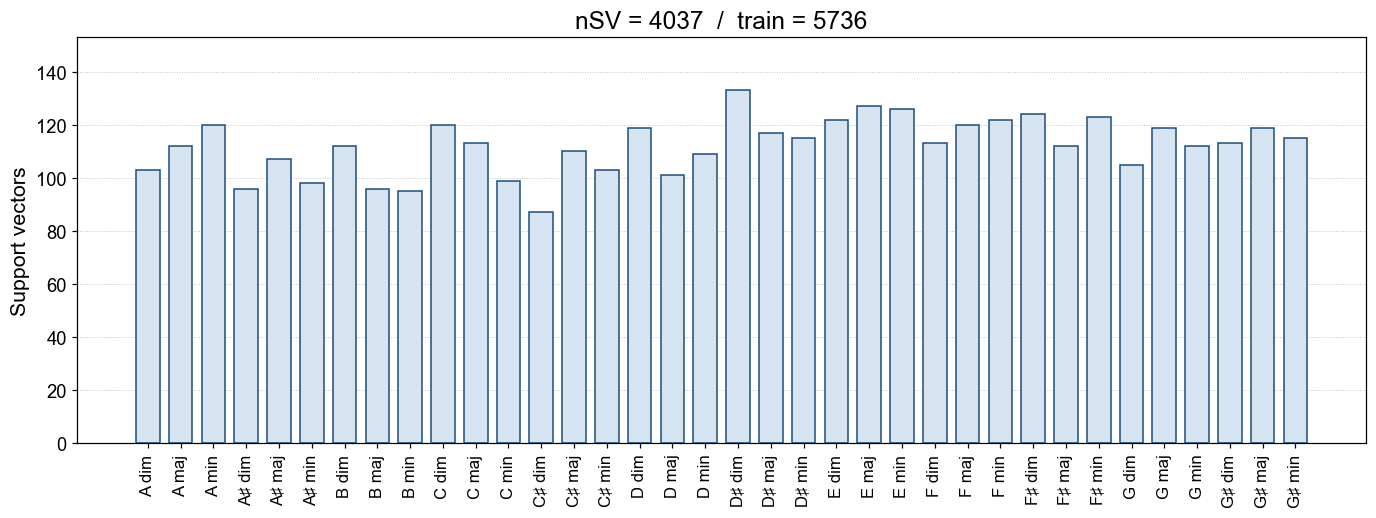

In [2]:
sv = pd.read_csv(RES / "support_seeds.csv")
sv = sv[(sv.variant == VARIANT) & (sv.seed == SEED)].copy()
sv["label"] = [pretty_class(c) for c in sv["class"]]
sv = sv.sort_values("label").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12.4, 4.6), layout="constrained")
x = np.arange(len(sv))
ax.bar(x, sv.n_support, width=0.72, facecolor=FILL, edgecolor=NAVY, linewidth=1.0)
ax.set_xticks(x, sv.label, rotation=90, fontsize=11)
ax.set_ylabel("Support vectors")
ax.set_ylim(0, int(sv.n_support.max()) + 20)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
ax.set_title(f"nSV = {int(sv.n_support.sum())}  /  train = {int(sv.n_train_class.sum())}")
plt.show()

### Fit log

```python
svm = SVC(kernel="rbf", C=1000, gamma=1e-5, cache_size=512, random_state=42)
svm.fit(X_train, y_train)
```

Reconstructed from `diagnostics.csv`, `ood_seeds.csv`, and `sink_seeds.csv` (not a live fit).

In [9]:
ood = pd.read_csv(RES / "ood_seeds.csv")
ood = ood[(ood.variant == VARIANT) & (ood.seed == SEED)]
sink = pd.read_csv(RES / "sink_seeds.csv")
sink = sink[(sink.variant == VARIANT) & (sink.seed == SEED)]

lines = [
    f"{VARIANT}/seed{SEED}: train {int(diag.n_train)} val {int(diag.n_val)} "
    f"test {int(diag.n_test)}",
    f"  fit {diag.fit_seconds:.1f}s  nSV {int(diag.n_sv_total)}",
    f"  gate OK {int(diag.fast_predict_n_checked)} rows, "
    f"min|dec| {diag.fast_predict_min_abs_dec:.3e}",
]
for ds in ["thinkpad", "vivo", "flow", "thinkpad-2", "flow-2"]:
    acc = float(ood.loc[ood.dataset == ds, "accuracy"].iloc[0])
    row = sink.loc[sink.dataset == ds].iloc[0]
    lines.append(
        f"  {ds:11s} acc {acc:.4f}  sink {row.sink_class} "
        f"{row.sink_share * 100:.1f}%"
    )
lines.append(
    f"OK {VARIANT}/seed{SEED}  test {diag.test_accuracy:.4f}  "
    f"{diag.predict_ms_per_clip:.2f} ms/clip"
)
print("\n".join(lines))

clean/seed42: train 5736 val 718 test 718
  fit 234.1s  nSV 4037
  gate OK 128 rows, min|dec| 1.652e-05
  thinkpad    acc 0.7889  sink C_diminished_4 20.8%
  vivo        acc 0.9701  sink E_minor_4 4.3%
  flow        acc 0.9931  sink C_diminished_4 3.1%
  thinkpad-2  acc 0.4271  sink C_diminished_4 46.7%
  flow-2      acc 0.6979  sink C_diminished_4 19.2%
OK clean/seed42  test 1.0000  1.64 ms/clip


## K-fold

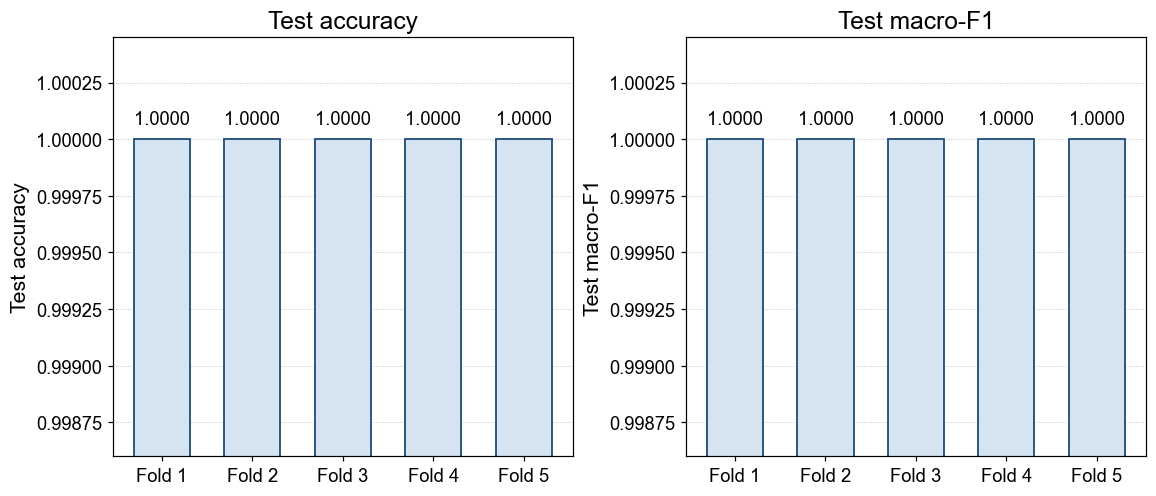

In [4]:
kf = pd.read_csv(RES / "kfold.csv")
kf = kf[kf.variant == VARIANT].sort_values("fold")
folds = kf.fold.to_numpy()
acc = kf.test_accuracy.to_numpy()
f1 = kf.test_macro_f1.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4), layout="constrained")
x = np.arange(len(folds))
xticklabels = [f"Fold {i + 1}" for i in folds]

for ax, vals, ylab in (
    (axes[0], acc, "Test accuracy"),
    (axes[1], f1, "Test macro-F1"),
):
    ax.bar(x, vals, width=0.62, facecolor=FILL, edgecolor=NAVY, linewidth=1.2)
    ax.set_xticks(x, xticklabels)
    ax.set_ylabel(ylab)
    ax.set_ylim(0.9986, 1.00045)
    for xi, v in zip(x, vals):
        ax.text(xi, v + 0.00005, f"{v:.4f}", ha="center", va="bottom", fontsize=12)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")

axes[0].set_title("Test accuracy")
axes[1].set_title("Test macro-F1")
plt.show()

## Confusion matrices

Every cell is annotated, including zeros. Counts are from the single clean seed-42 run.

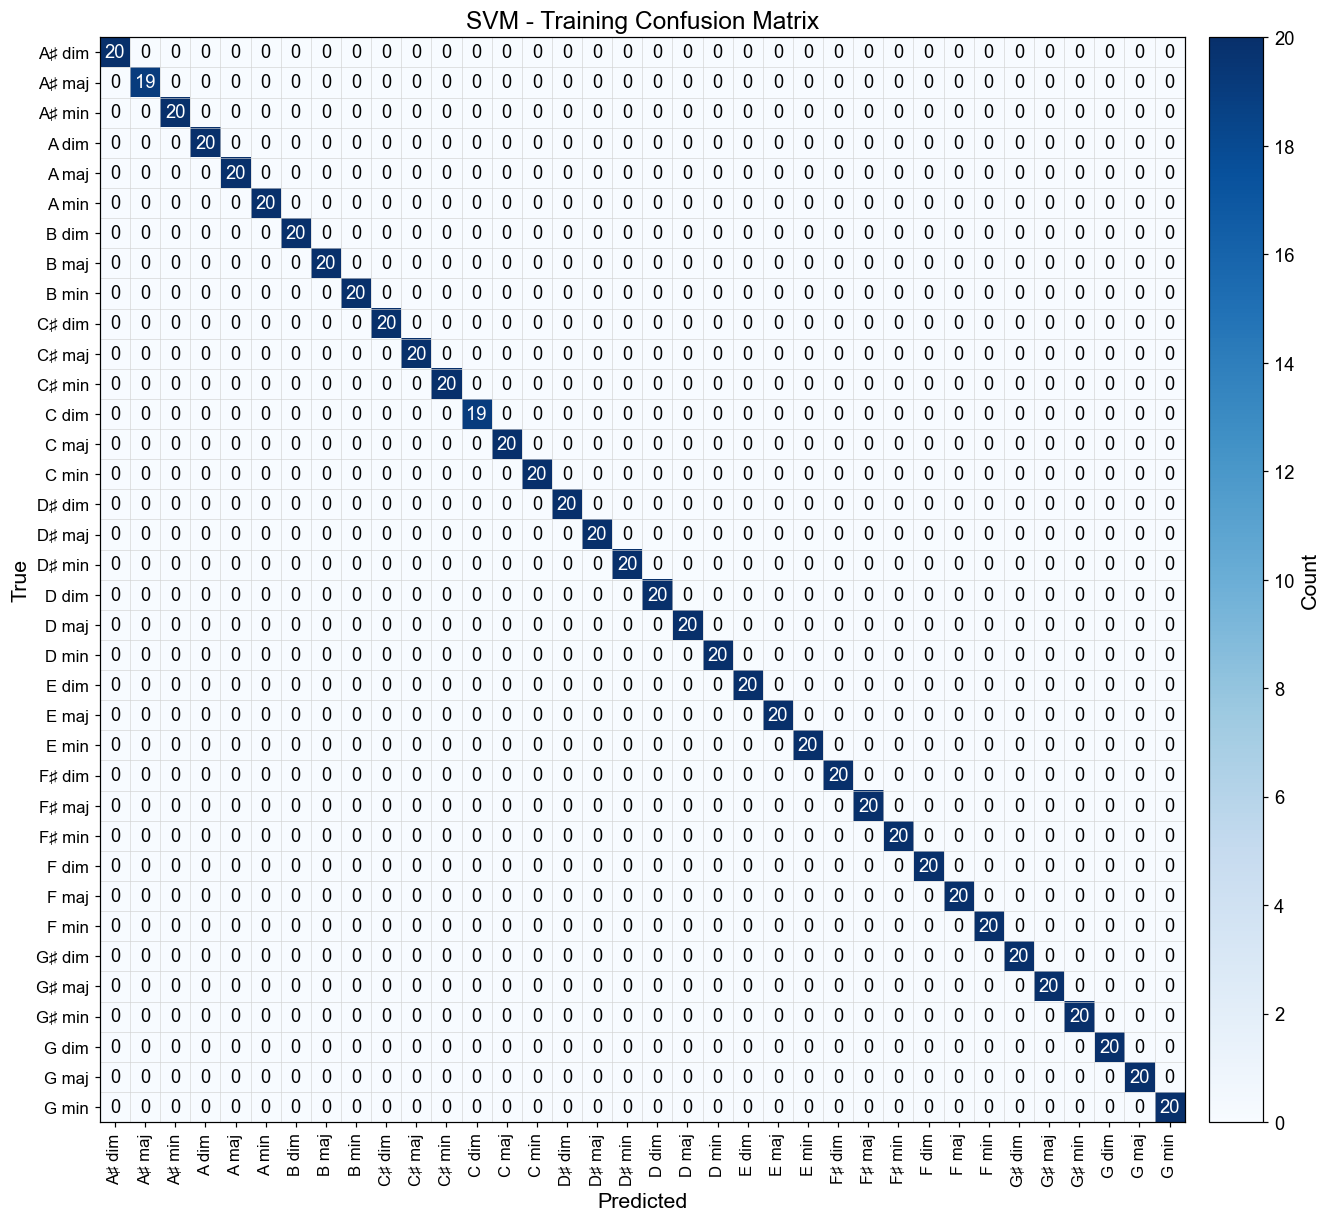

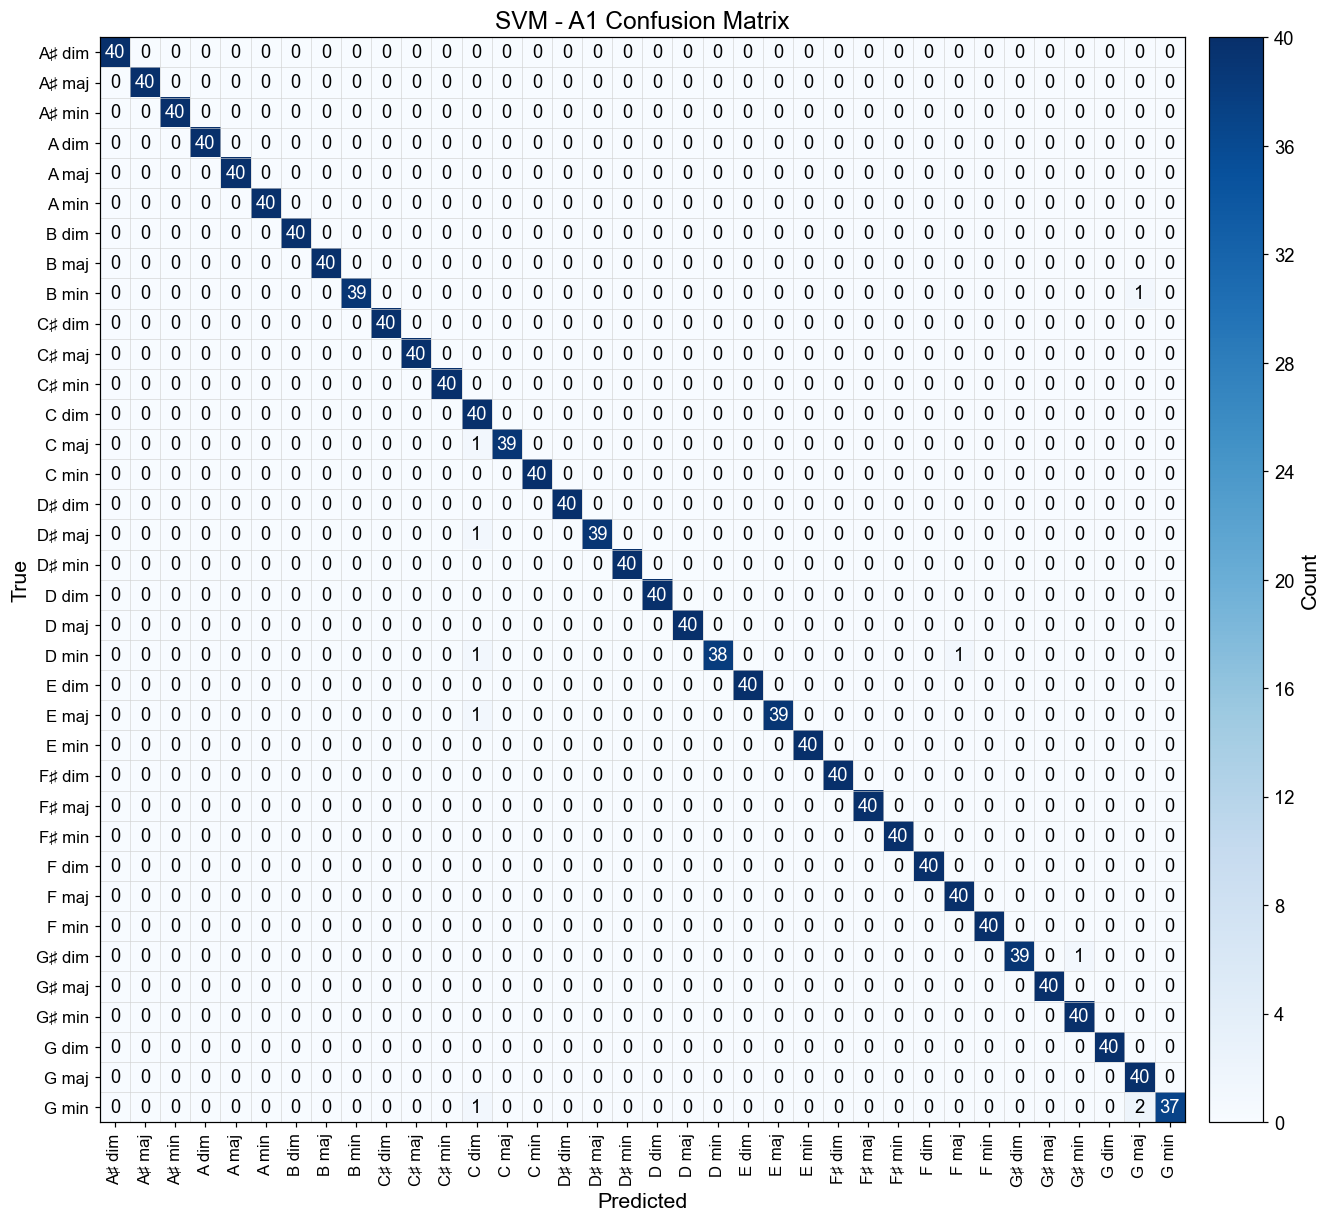

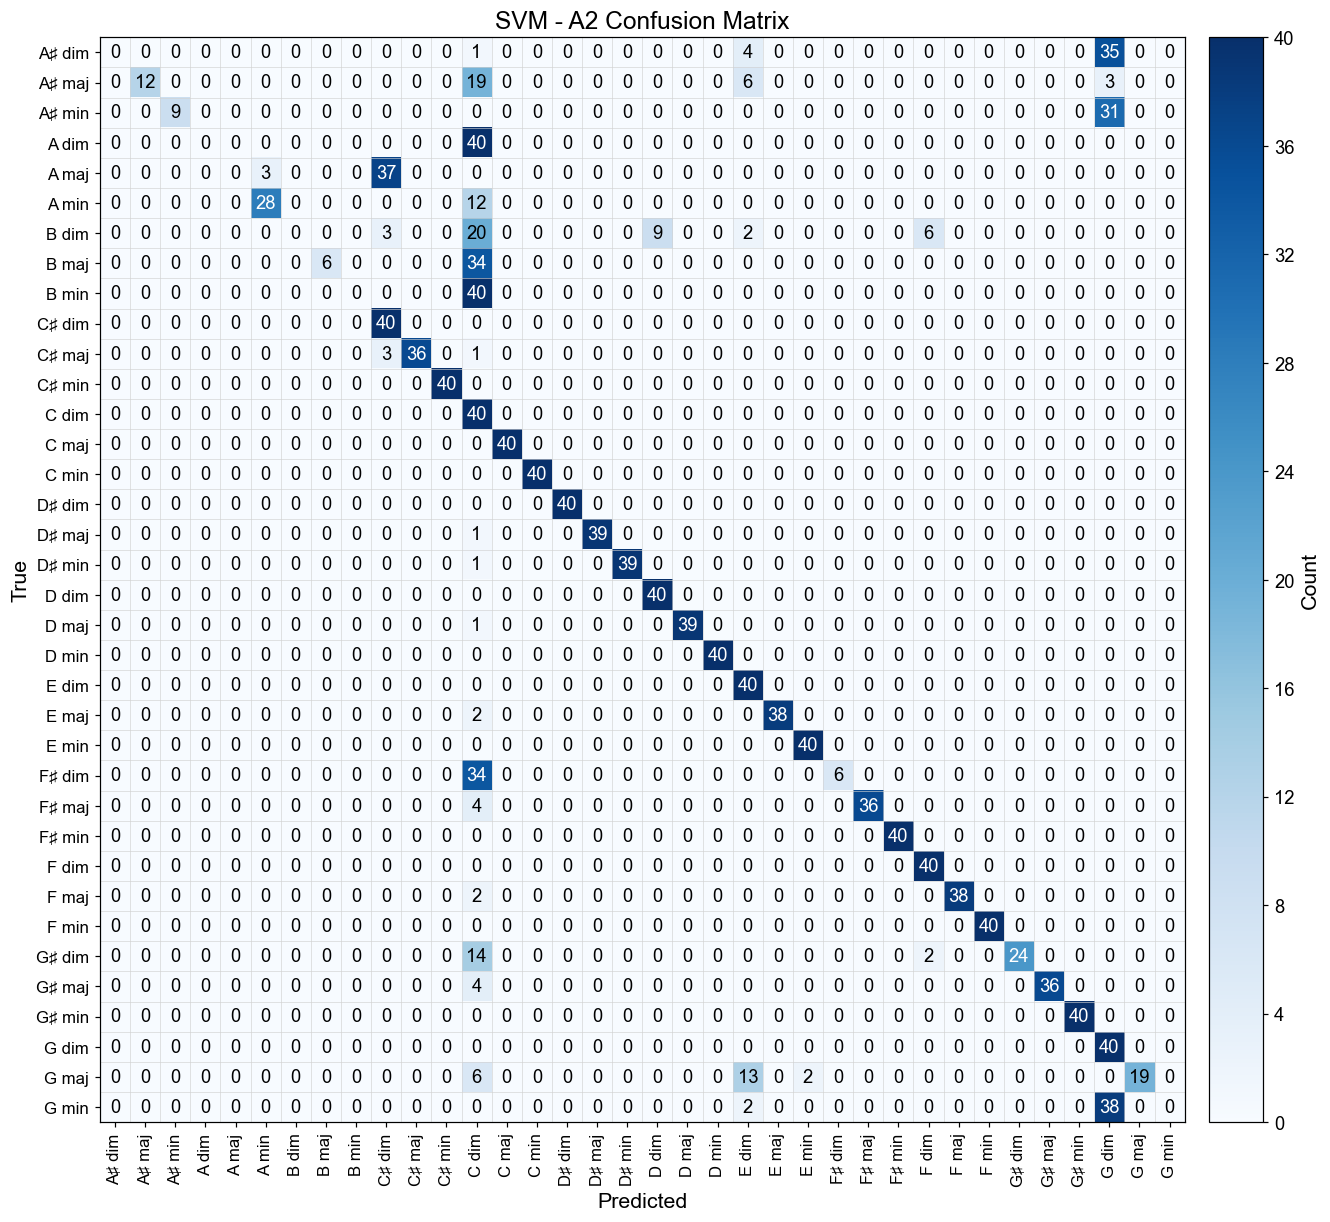

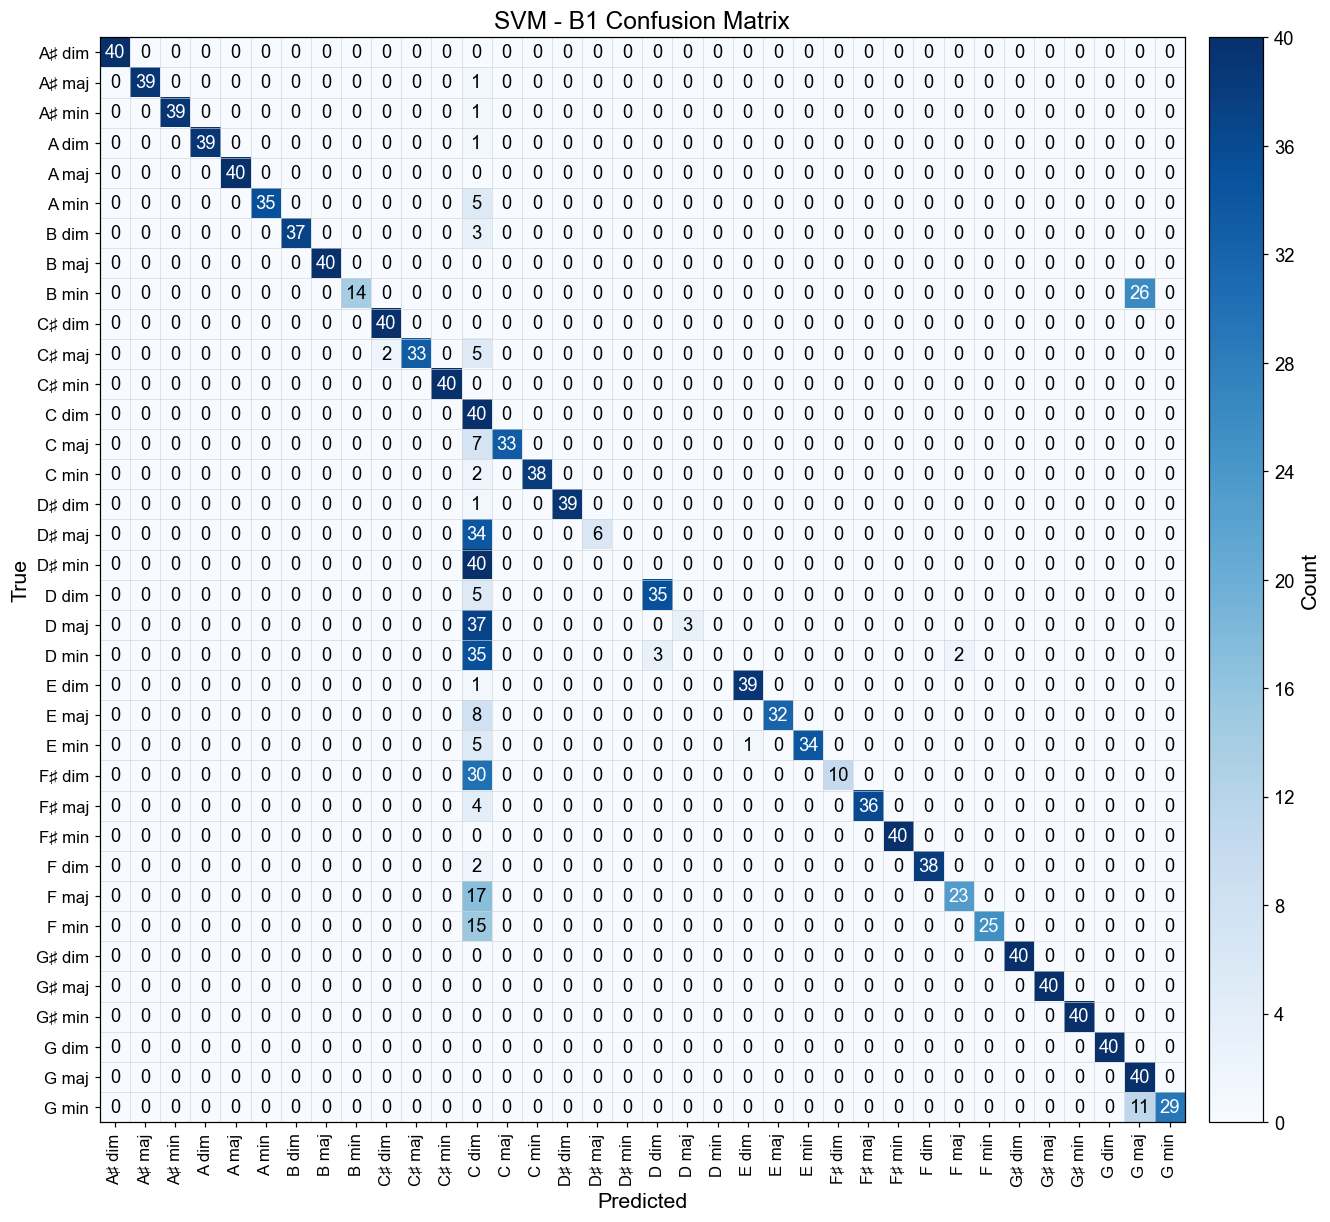

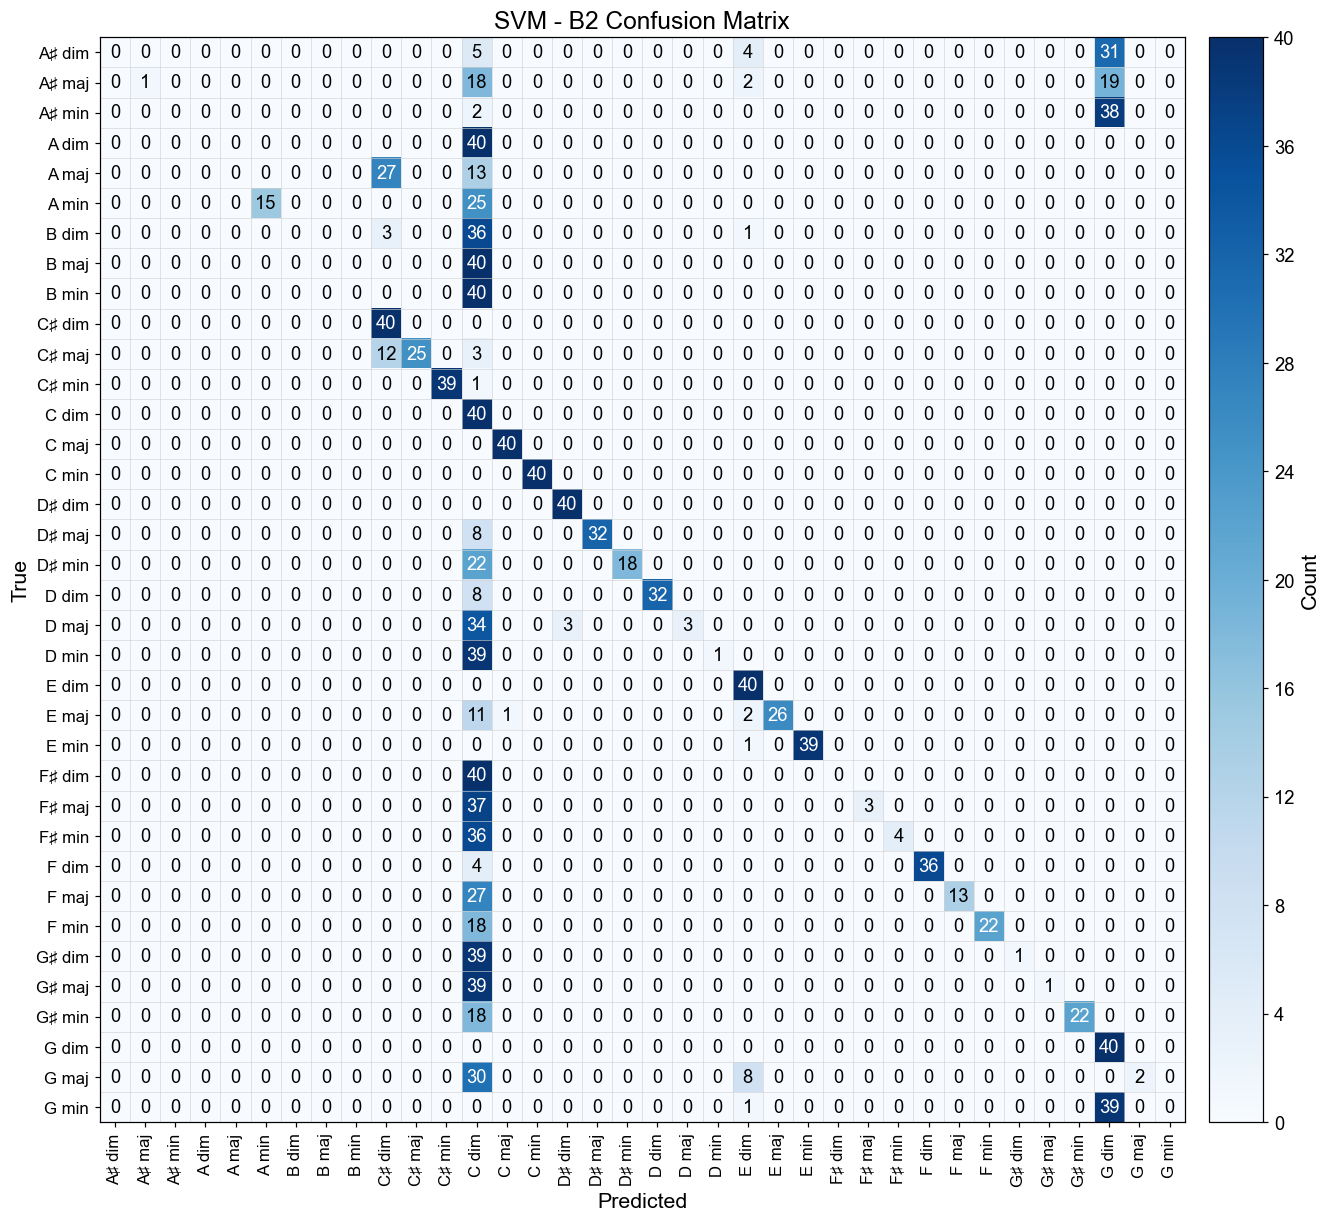

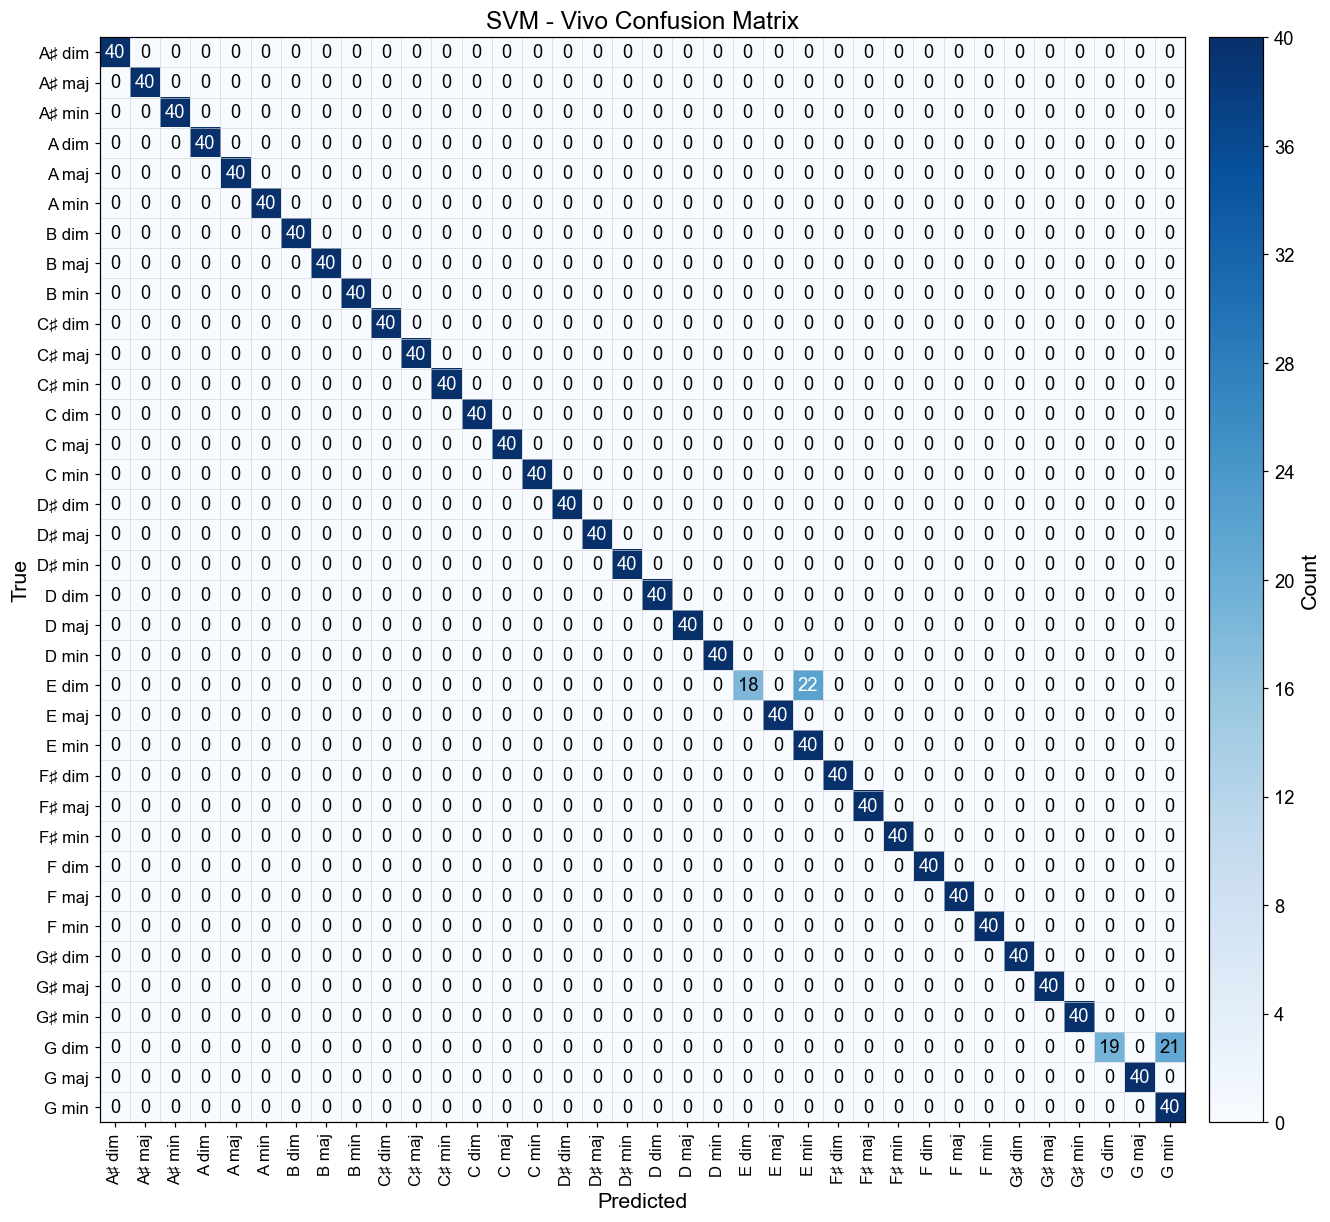

In [5]:
names = class_names()
show_cm("training", *training_cm())
for ds in OOD:
    cm = load_cm(ds)
    show_cm(ds, cm.loc[names, names].to_numpy(dtype=float), names)

## Evaluation metrics

Macro precision, recall, and F1 from the same clean seed-42 run as the plots. Mean and std are over the rows above them.

In [6]:
names = class_names()
rows = []
PER_CLASS = {}
items = [("training", *training_cm())]
for ds in OOD:
    cm = load_cm(ds)
    items.append((ds, cm.loc[names, names].to_numpy(dtype=float), names))
for ds, mat, cls in items:
    per_class, summary = metrics_from_cm(mat, cls)
    PER_CLASS[ds] = per_class
    rows.append({"evaluation": LABEL[ds], **summary})

summary_df = with_mean_std(pd.DataFrame(rows), "evaluation")
display(Markdown("### Recorded evaluations"))
display(summary_df.round(4))

### Recorded evaluations

,evaluation,accuracy,precision,recall,f1-score
0,Training,1.0000,1.0000,1.0000,1.0000
1,A1,0.9931,0.9936,0.9931,0.9931
2,A2,0.6979,0.7500,0.6979,0.6708
3,B1,0.7889,0.9006,0.7889,0.7989
4,B2,0.4271,0.6770,0.4271,0.4166
5,Vivo,0.9701,0.9806,0.9701,0.9678
6,mean,0.8128,0.8836,0.8128,0.8079
7,std,0.2258,0.1385,0.2258,0.2318


### K-fold

In [7]:
kf = pd.read_csv(RES / "kfold.csv")
kf = kf[kf.variant == VARIANT].sort_values("fold")
kfold_df = pd.DataFrame(
    {
        "fold": [f"Fold {int(f) + 1}" for f in kf.fold],
        "accuracy": kf.test_accuracy.to_numpy(),
        "precision": kf.test_macro_precision.to_numpy(),
        "recall": kf.test_macro_recall.to_numpy(),
        "f1-score": kf.test_macro_f1.to_numpy(),
    }
)
display(with_mean_std(kfold_df, "fold").round(4))

,fold,accuracy,precision,recall,f1-score
0,Fold 1,1.0,1.0,1.0,1.0
1,Fold 2,1.0,1.0,1.0,1.0
2,Fold 3,1.0,1.0,1.0,1.0
3,Fold 4,1.0,1.0,1.0,1.0
4,Fold 5,1.0,1.0,1.0,1.0
5,mean,1.0,1.0,1.0,1.0
6,std,0.0,0.0,0.0,0.0


## Per-class metrics

Only classes with accuracy below 1.0. Precision and F1 are shown for those same rows.

In [8]:
cols = ["class", "precision", "recall", "f1-score", "accuracy", "support"]
for ds, per_class in PER_CLASS.items():
    imperfect = (
        per_class.loc[per_class.accuracy < 1.0, cols]
        .sort_values(["accuracy", "class"])
        .reset_index(drop=True)
    )
    display(Markdown(f"### {LABEL[ds]}"))
    if imperfect.empty:
        display(pd.DataFrame([{"note": "every class has accuracy 1.0"}]))
    else:
        display(imperfect.round(4))

### Training

,note
0,every class has accuracy 1.0


### A1

,class,precision,recall,f1-score,accuracy,support
0,G min,1.0,0.925,0.9610,0.925,40
1,D min,1.0,0.950,0.9744,0.950,40
2,B min,1.0,0.975,0.9873,0.975,40
3,C maj,1.0,0.975,0.9873,0.975,40
4,D♯ maj,1.0,0.975,0.9873,0.975,40
5,E maj,1.0,0.975,0.9873,0.975,40
6,G♯ dim,1.0,0.975,0.9873,0.975,40


### A2

...

,class,precision,recall,f1-score,accuracy,support
0,D min,0.0000,0.000,0.0000,0.000,40
1,D♯ min,0.0000,0.000,0.0000,0.000,40
2,D maj,1.0000,0.075,0.1395,0.075,40
3,D♯ maj,1.0000,0.150,0.2609,0.150,40
4,F♯ dim,1.0000,0.250,0.4000,0.250,40
5,B min,1.0000,0.350,0.5185,0.350,40
6,F maj,0.9200,0.575,0.7077,0.575,40
7,F min,1.0000,0.625,0.7692,0.625,40
8,G min,1.0000,0.725,0.8406,0.725,40
9,E maj,1.0000,0.800,0.8889,0.800,40


### B2

,class,precision,recall,f1-score,accuracy,support
0,A dim,0.0,0.000,0.0000,0.000,40
1,A maj,0.0,0.000,0.0000,0.000,40
2,A♯ dim,0.0,0.000,0.0000,0.000,40
3,A♯ min,0.0,0.000,0.0000,0.000,40
4,B dim,0.0,0.000,0.0000,0.000,40
5,B maj,0.0,0.000,0.0000,0.000,40
6,B min,0.0,0.000,0.0000,0.000,40
7,F♯ dim,0.0,0.000,0.0000,0.000,40
8,G min,0.0,0.000,0.0000,0.000,40
9,A♯ maj,1.0,0.025,0.0488,0.025,40


### Vivo

,class,precision,recall,f1-score,accuracy,support
0,E dim,1.0,0.450,0.6207,0.450,40
1,G dim,1.0,0.475,0.6441,0.475,40
